Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves.csv
5-yr: fraction (≥ 1.0 m) ≈ 0.1599 (threshold used 1.00 m) [land denom]
5-yr: fraction (≥ 2.0 m) ≈ 0.0998 (threshold used 2.00 m) [land denom]
50-yr: fraction (≥ 1.0 m) ≈ 0.8767 (threshold used 1.00 m) [land denom]
50-yr: fraction (≥ 2.0 m) ≈ 0.7925 (threshold used 2.00 m) [land denom]
100-yr: fraction (≥ 1.0 m) ≈ 0.9411 (threshold used 1.00 m) [land denom]
100-yr: fraction (≥ 2.0 m) ≈ 0.8685 (threshold used 2.00 m) [land denom]


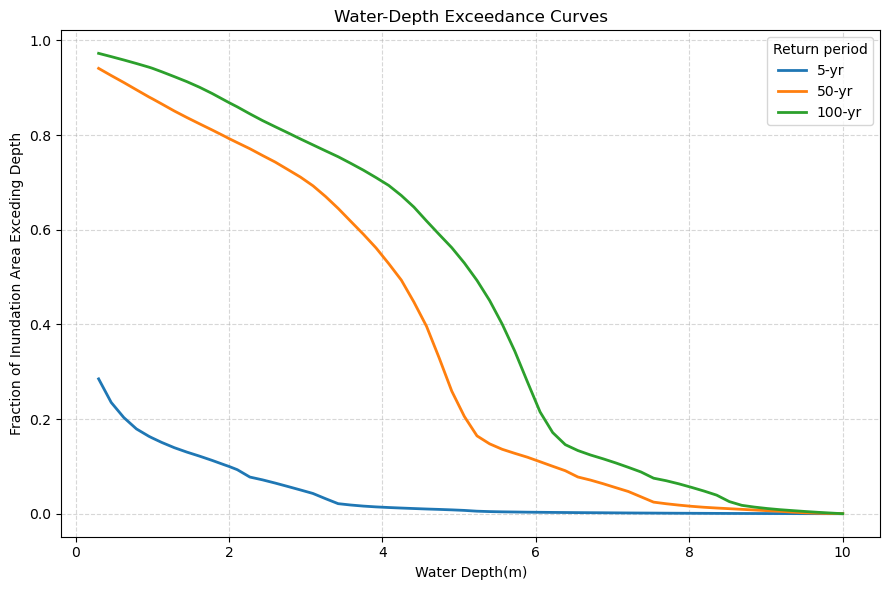

In [5]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ USER INPUTS ------------------
raster_paths = [
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_5yr.tif",
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_50yr.tif",
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_100yr.tif",
]
labels = ["5-yr", "50-yr", "100-yr"]  # legend labels
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance computation settings
FLOOD_PRESENCE_THRESH = 0.3  # cells >= this are considered "flooded"
DEPTH_CAP = 10             # e.g., set to 5.0 to consider only 0–5 m
DENOMINATOR = "land"         # "land" (fraction of total land area) or "flooded" (fraction of total inundated area)
N_THRESH = 60                # number of thresholds for smooth curves
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # extra thresholds to annotate/report

# -------------------------------------------------

def load_and_clip(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        # project boundary to raster CRS
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # clean: NoData -> NaN, negatives -> NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    # optional cap (e.g., 0–5 m)
    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # pixel area (m²)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # land area from boundary in raster CRS (m²)
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

# Read boundary (should be EPSG:32614 so areas are in meters)
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set EPSG:32614 (or the raster CRS) before proceeding.")

curves = []  # to collect data for CSV
plt.figure(figsize=(9, 6))

for rp_path, lab in zip(raster_paths, labels):
    depth_ma, cell_area_m2, land_area_m2 = load_and_clip(rp_path, boundary)

    # auto threshold range based on data
    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid depth values after masking for: {lab}")
        continue

    dmin = np.nanmax([FLOOD_PRESENCE_THRESH, np.nanmin(valid_vals)])
    dmax = np.nanmax(valid_vals) if DEPTH_CAP is None else min(DEPTH_CAP, np.nanmax(valid_vals))

    # create thresholds (include manual ones)
    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(thr_auto.tolist() + MANUAL_THRESHOLDS), dmin, dmax))

    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator area for: {lab}")
        continue

    # compute fractions for exceedance
    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    # store for CSV
    curves.append(pd.DataFrame({
        "return_period": lab,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    }))

    # plot
    plt.plot(thresholds, frac, label=lab, linewidth=2)

# Styling
#ylabel = "Fraction of land area" if DENOMINATOR == "land" else "Fraction of inundated area"
plt.xlabel("Water Depth(m)")
plt.ylabel("Fraction of Inundation Area Exceding Depth")
plt.title("Water-Depth Exceedance Curves")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Return period")
plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

# Also print quick lookup for 1 m and 2 m exactly (if in range)
def lookup_at(depth_m, df):
    # find nearest threshold
    i = (df["threshold_m"] - depth_m).abs().idxmin()
    return df.loc[i, "threshold_m"], df.loc[i, df.columns[-1]]

if curves:
    for lab in labels:
        sub = df_all[df_all["return_period"] == lab].reset_index(drop=True)
        for d in [1.0, 2.0]:
            
            if sub["threshold_m"].min() <= d <= sub["threshold_m"].max():
                td, frac = lookup_at(d, sub)
                print(f"{lab}: fraction (≥ {d:.1f} m) ≈ {frac:.4f} (threshold used {td:.2f} m) [{DENOMINATOR} denom]")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves.csv
5-yr: fraction (≥ 1.0 m) ≈ 0.1616 (threshold used 1.00 m) [land denom]
5-yr: fraction (≥ 2.0 m) ≈ 0.1015 (threshold used 2.00 m) [land denom]
50-yr: fraction (≥ 1.0 m) ≈ 0.8833 (threshold used 1.00 m) [land denom]
50-yr: fraction (≥ 2.0 m) ≈ 0.7992 (threshold used 2.00 m) [land denom]
100-yr: fraction (≥ 1.0 m) ≈ 0.9544 (threshold used 1.00 m) [land denom]
100-yr: fraction (≥ 2.0 m) ≈ 0.8818 (threshold used 2.00 m) [land denom]


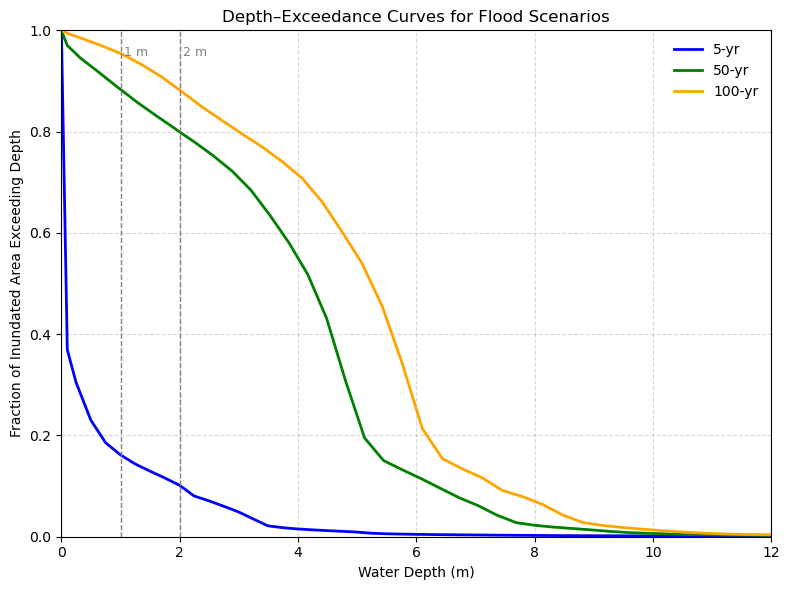

In [7]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ USER INPUTS ------------------
raster_paths = [
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_5yr.tif",
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_50yr.tif",
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_100yr.tif",
]
labels = ["5-yr", "50-yr", "100-yr"]  # legend labels
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance computation settings
FLOOD_PRESENCE_THRESH = 0.0
DEPTH_CAP = None
DENOMINATOR = "land"  # "land" or "flooded"
N_THRESH = 60
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]

# Optional custom colors (optional; modify as needed)
custom_colors = {
    "5-yr": "blue",
    "50-yr": "green",
    "100-yr": "orange",
}

# -------------------------------------------------

def load_and_clip(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

# Read boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set EPSG:32614 (or the raster CRS) before proceeding.")

curves = []
plt.figure(figsize=(8, 6))

for rp_path, lab in zip(raster_paths, labels):
    depth_ma, cell_area_m2, land_area_m2 = load_and_clip(rp_path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid depth values after masking for: {lab}")
        continue

    dmin = np.nanmax([FLOOD_PRESENCE_THRESH, np.nanmin(valid_vals)])
    dmax = np.nanmax(valid_vals) if DEPTH_CAP is None else min(DEPTH_CAP, np.nanmax(valid_vals))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(thr_auto.tolist() + MANUAL_THRESHOLDS), dmin, dmax))

    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator area for: {lab}")
        continue

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    curves.append(pd.DataFrame({
        "return_period": lab,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    }))

    plt.plot(thresholds, frac, label=lab, linewidth=2, color=custom_colors.get(lab, None))

# Plot styling to match example
plt.xlabel("Water Depth (m)")
plt.ylabel("Fraction of Inundated Area Exceeding Depth")
plt.title("Depth–Exceedance Curves for Flood Scenarios")
plt.xlim(0, 12)
plt.ylim(0, 1.0)
plt.grid(True, linestyle="--", alpha=0.5)

# Vertical lines at 1 m and 2 m
for d in [1.0, 2.0]:
    plt.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    plt.text(d + 0.05, 0.95, f"{int(d)} m", rotation=0, color='gray', fontsize=9)

# Legend (clean)
plt.legend(
    title=None,
    loc='upper right',
    frameon=False
)

plt.tight_layout()

# Save CSV
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

# Optional: print quick lookups
def lookup_at(depth_m, df):
    i = (df["threshold_m"] - depth_m).abs().idxmin()
    return df.loc[i, "threshold_m"], df.loc[i, df.columns[-1]]

if curves:
    for lab in labels:
        sub = df_all[df_all["return_period"] == lab].reset_index(drop=True)
        for d in [1.0, 2.0]:
            if sub["threshold_m"].min() <= d <= sub["threshold_m"].max():
                td, frac = lookup_at(d, sub)
                print(f"{lab}: fraction (≥ {d:.1f} m) ≈ {frac:.4f} (threshold used {td:.2f} m) [{DENOMINATOR} denom]")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves.csv
5-yr: fraction (≥ 1.0 m) ≈ 0.1616 (threshold used 1.00 m) [flooded denom]
5-yr: fraction (≥ 2.0 m) ≈ 0.1015 (threshold used 2.00 m) [flooded denom]
50-yr: fraction (≥ 1.0 m) ≈ 0.8835 (threshold used 1.00 m) [flooded denom]
50-yr: fraction (≥ 2.0 m) ≈ 0.7993 (threshold used 2.00 m) [flooded denom]
100-yr: fraction (≥ 1.0 m) ≈ 0.9546 (threshold used 1.00 m) [flooded denom]
100-yr: fraction (≥ 2.0 m) ≈ 0.8820 (threshold used 2.00 m) [flooded denom]


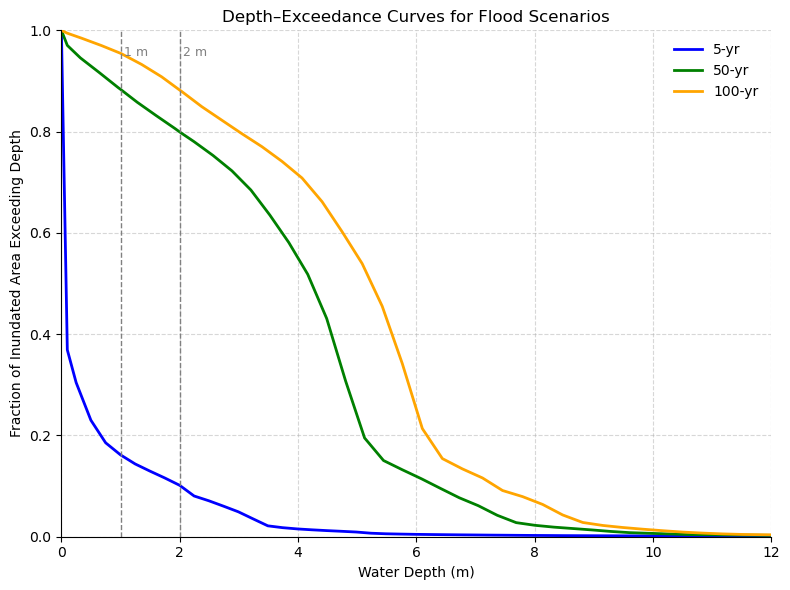

In [8]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ USER INPUTS ------------------
raster_paths = [
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_5yr.tif",
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_50yr.tif",
    r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_100yr.tif",
]
labels = ["5-yr", "50-yr", "100-yr"]  # legend labels
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance computation settings
FLOOD_PRESENCE_THRESH = 0.0
DEPTH_CAP = None
DENOMINATOR = "flooded"  # "land" or "flooded"
N_THRESH = 60
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]

# Optional custom colors
custom_colors = {
    "5-yr": "blue",
    "50-yr": "green",
    "100-yr": "orange",
}

# -------------------------------------------------

def load_and_clip(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

# Read boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set EPSG:32614 (or the raster CRS) before proceeding.")

curves = []
plt.figure(figsize=(8, 6))

for rp_path, lab in zip(raster_paths, labels):
    depth_ma, cell_area_m2, land_area_m2 = load_and_clip(rp_path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid depth values after masking for: {lab}")
        continue

    dmin = np.nanmax([FLOOD_PRESENCE_THRESH, np.nanmin(valid_vals)])
    dmax = np.nanmax(valid_vals) if DEPTH_CAP is None else min(DEPTH_CAP, np.nanmax(valid_vals))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(thr_auto.tolist() + MANUAL_THRESHOLDS), dmin, dmax))

    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator area for: {lab}")
        continue

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    curves.append(pd.DataFrame({
        "return_period": lab,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    }))

    plt.plot(thresholds, frac, label=lab, linewidth=2, color=custom_colors.get(lab, None))

# Plot styling to match example
plt.xlabel("Water Depth (m)")
plt.ylabel("Fraction of Inundated Area Exceeding Depth")
plt.title("Depth–Exceedance Curves for Flood Scenarios")
plt.xlim(0, 12)
plt.ylim(0, 1.0)
plt.grid(True, linestyle="--", alpha=0.5)

# Vertical lines at 1 m and 2 m
for d in [1.0, 2.0]:
    plt.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    plt.text(d + 0.05, 0.95, f"{int(d)} m", rotation=0, color='gray', fontsize=9)

# Legend (clean)
plt.legend(
    title=None,
    loc='upper right',
    frameon=False
)

# Remove top and right spines (outlines)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save CSV
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

# Optional: print quick lookups
def lookup_at(depth_m, df):
    i = (df["threshold_m"] - depth_m).abs().idxmin()
    return df.loc[i, "threshold_m"], df.loc[i, df.columns[-1]]

if curves:
    for lab in labels:
        sub = df_all[df_all["return_period"] == lab].reset_index(drop=True)
        for d in [1.0, 2.0]:
            if sub["threshold_m"].min() <= d <= sub["threshold_m"].max():
                td, frac = lookup_at(d, sub)
                print(f"{lab}: fraction (≥ {d:.1f} m) ≈ {frac:.4f} (threshold used {td:.2f} m) [{DENOMINATOR} denom]")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr.csv
Surge only (100-yr): fraction (≥ 1.0 m) ≈ 0.8220 (threshold used 1.00 m) [land denom]
Surge only (100-yr): fraction (≥ 2.0 m) ≈ 0.7364 (threshold used 2.00 m) [land denom]
Compound flood (100-yr): fraction (≥ 1.0 m) ≈ 0.9544 (threshold used 1.00 m) [land denom]
Compound flood (100-yr): fraction (≥ 2.0 m) ≈ 0.8818 (threshold used 2.00 m) [land denom]
FEMA 100-yr flood: fraction (≥ 1.0 m) ≈ 0.0704 (threshold used 1.00 m) [land denom]
FEMA 100-yr flood: fraction (≥ 2.0 m) ≈ 0.0340 (threshold used 2.00 m) [land denom]


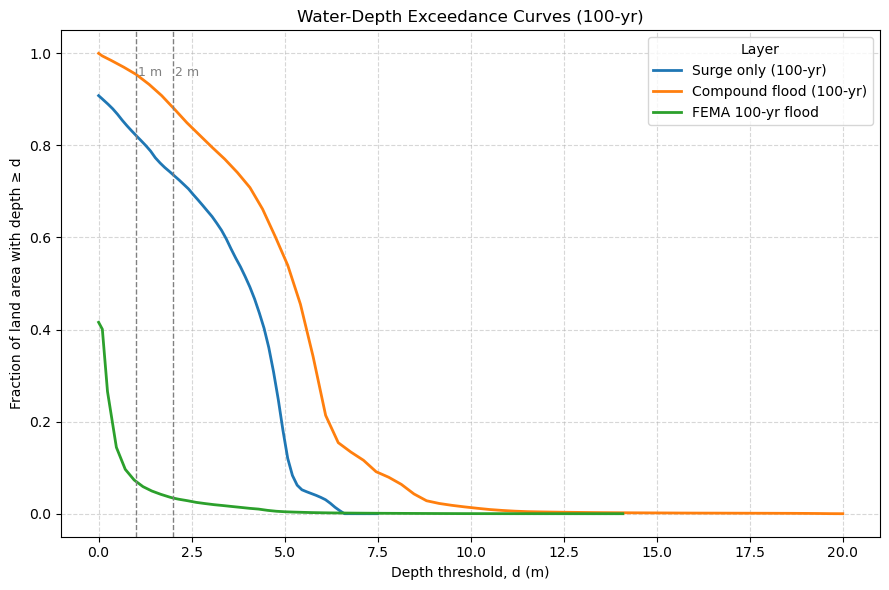

In [10]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Surge only (100-yr)": r"C:\Users\sahad2\Research_data\Raster\surge_only_btub_Depth_100yr_6.5_msk_nonnegative.tif",
    "Compound flood (100-yr)": r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_100yr.tif",
    "FEMA 100-yr flood": r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.0   # cells >= this are considered "flooded" when using DENOMINATOR="flooded"
DENOMINATOR = "land"          # "land" or "flooded"
DEPTH_CAP = None              # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 60                 # curve resolution
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # ensure these are included
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData -> NaN, negatives -> NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    # Optional cap (e.g., 0–5 m)
    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel area (m²) from transform
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # Land area from boundary in raster CRS (m²)
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def is_binary_extent(vals, tol=1e-9):
    """Heuristic: treat as extent if unique finite values subset of {0, 1} (within tol)."""
    u = np.unique(vals)
    u = u[np.isfinite(u)]
    if u.size == 0:
        return False
    return np.all((np.abs(u - 0) < tol) | (np.abs(u - 1) < tol))

# Load boundary (projected CRS in meters recommended, e.g., EPSG:32614)
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
plt.figure(figsize=(9, 6))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    # Determine if this raster is a binary flood extent (e.g., FEMA)
    valid_vals = depth_ma.compressed()
    treat_as_extent = is_binary_extent(valid_vals)

    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # Threshold range
    if treat_as_extent:
        # Build a tiny range around 0..1 to draw a step-like curve
        dmin, dmax = 0.0, 1.0
    else:
        dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
        dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    # Denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH) if not treat_as_extent else (depth_ma > 0)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    # Exceedance fractions
    frac = []
    if treat_as_extent:
        # If binary, area with depth>=t equals flooded area for t <= 1, else 0
        for t in thresholds:
            exceed_area_m2 = flooded_area_m2 if t <= 1.0 else 0.0
            frac.append(exceed_area_m2 / denom_area_m2)
    else:
        for t in thresholds:
            exceed_mask = (depth_ma >= t)
            exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
            frac.append(exceed_area_m2 / denom_area_m2)

    # Store & plot
    df = pd.DataFrame({
        "layer": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    plt.plot(thresholds, frac, label=label, linewidth=2)

# Decorate plot
ylabel = "Fraction of land area" if DENOMINATOR == "land" else "Fraction of inundated area"
plt.xlabel("Depth threshold, d (m)")
plt.ylabel(ylabel + " with depth ≥ d")
plt.title("Water-Depth Exceedance Curves (100-yr)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Layer")
plt.tight_layout()

# Vertical lines at 1 m and 2 m
for d in [1.0, 2.0]:
    plt.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    plt.text(d + 0.05, 0.95, f"{int(d)} m", rotation=0, color='gray', fontsize=9)
# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

    # Quick lookup at 1 m and 2 m if present in range
    def lookup_at(depth_m, df):
        i = (df["threshold_m"] - depth_m).abs().idxmin()
        return df.loc[i, "threshold_m"], df.loc[i, df.columns[-1]]

    for label in raster_paths.keys():
        sub = df_all[df_all["layer"] == label].reset_index(drop=True)
        for d in [1.0, 2.0]:
            if sub["threshold_m"].min() <= d <= sub["threshold_m"].max():
                td, f = lookup_at(d, sub)
                print(f"{label}: fraction (≥ {d:.1f} m) ≈ {f:.4f} (threshold used {td:.2f} m) [{DENOMINATOR} denom]")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr.csv
Surge only (100-yr): fraction (≥ 1.0 m) ≈ 0.8220 (threshold used 1.00 m) [land denom]
Surge only (100-yr): fraction (≥ 2.0 m) ≈ 0.7364 (threshold used 2.00 m) [land denom]
Compound flood (100-yr): fraction (≥ 1.0 m) ≈ 0.9544 (threshold used 1.00 m) [land denom]
Compound flood (100-yr): fraction (≥ 2.0 m) ≈ 0.8818 (threshold used 2.00 m) [land denom]
FEMA 100-yr flood: fraction (≥ 1.0 m) ≈ 0.0704 (threshold used 1.00 m) [land denom]
FEMA 100-yr flood: fraction (≥ 2.0 m) ≈ 0.0340 (threshold used 2.00 m) [land denom]


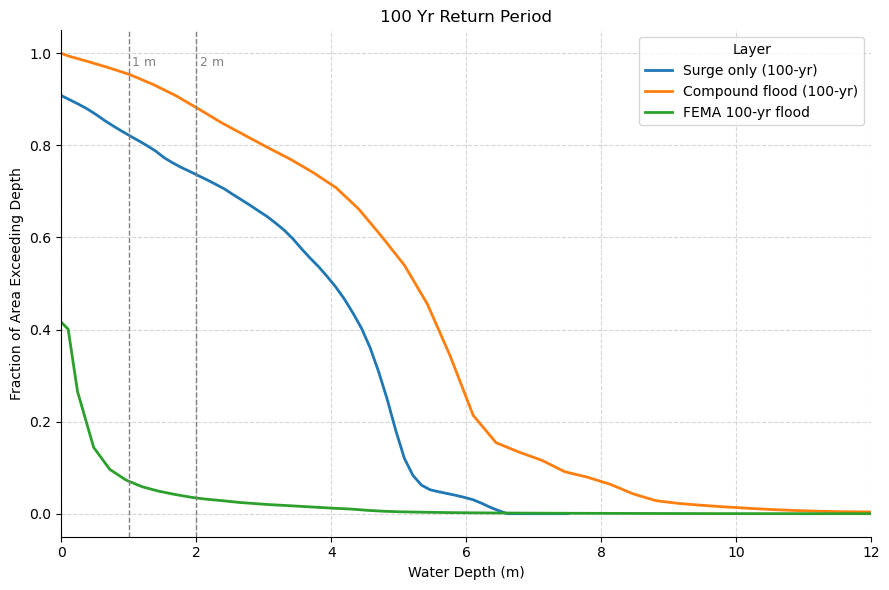

In [11]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Surge only (100-yr)": r"C:\Users\sahad2\Research_data\Raster\surge_only_btub_Depth_100yr_6.5_msk_nonnegative.tif",
    "Compound flood (100-yr)": r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_100yr.tif",
    "FEMA 100-yr flood": r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.0   # cells >= this are considered "flooded" when using DENOMINATOR="flooded"
DENOMINATOR = "land"          # "land" or "flooded"
DEPTH_CAP = None              # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 60                 # curve resolution
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # ensure these are included
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData -> NaN, negatives -> NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    # Optional cap (e.g., 0–5 m)
    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel area (m²) from transform
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # Land area from boundary in raster CRS (m²)
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def is_binary_extent(vals, tol=1e-9):
    """Heuristic: treat as extent if unique finite values subset of {0, 1} (within tol)."""
    u = np.unique(vals)
    u = u[np.isfinite(u)]
    if u.size == 0:
        return False
    return np.all((np.abs(u - 0) < tol) | (np.abs(u - 1) < tol))

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(9, 6))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    # Determine if this raster is a binary flood extent (e.g., FEMA)
    valid_vals = depth_ma.compressed()
    treat_as_extent = is_binary_extent(valid_vals)

    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # Threshold range
    if treat_as_extent:
        dmin, dmax = 0.0, 1.0
    else:
        dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
        dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    # Denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH) if not treat_as_extent else (depth_ma > 0)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    # Exceedance fractions
    frac = []
    if treat_as_extent:
        for t in thresholds:
            exceed_area_m2 = flooded_area_m2 if t <= 1.0 else 0.0
            frac.append(exceed_area_m2 / denom_area_m2)
    else:
        for t in thresholds:
            exceed_mask = (depth_ma >= t)
            exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
            frac.append(exceed_area_m2 / denom_area_m2)

    # Store & plot
    df = pd.DataFrame({
        "layer": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks per your request ----
# Remove top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels and title
ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
ax.set_title("100 Yr Return Period")

# Grid, legend, limits
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(title= None)
ax.set_xlim(0, 12)  # x-axis range 0..12 m

# Vertical guide lines at 1 m and 2 m (optional)
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.05, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=9, color='gray')

plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

    # Quick lookup at 1 m and 2 m if present in range
    def lookup_at(depth_m, df):
        i = (df["threshold_m"] - depth_m).abs().idxmin()
        return df.loc[i, "threshold_m"], df.loc[i, df.columns[-1]]

    for label in raster_paths.keys():
        sub = df_all[df_all["layer"] == label].reset_index(drop=True)
        for d in [1.0, 2.0]:
            if sub["threshold_m"].min() <= d <= sub["threshold_m"].max():
                td, f = lookup_at(d, sub)
                print(f"{label}: fraction (≥ {d:.1f} m) ≈ {f:.4f} (threshold used {td:.2f} m) [{DENOMINATOR} denom]")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr.csv


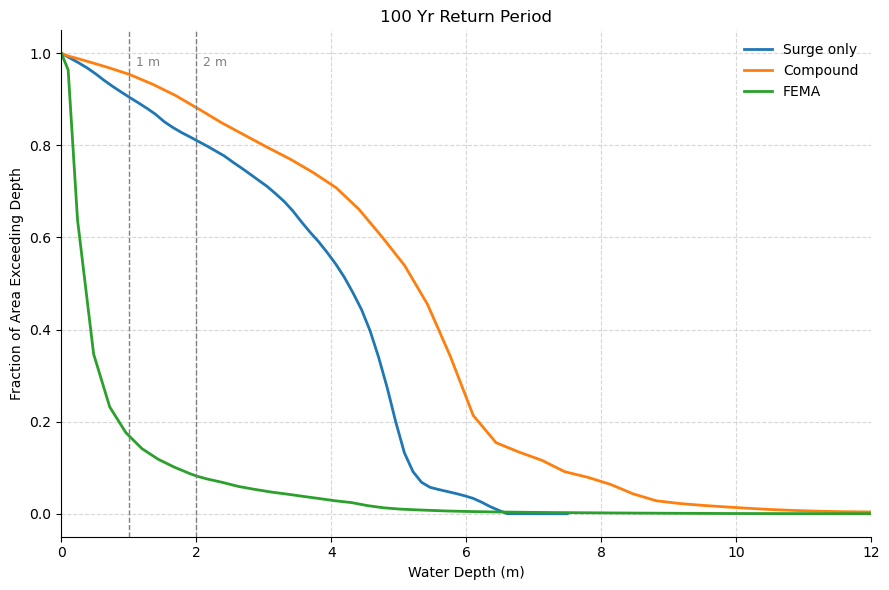

In [14]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Surge only (100-yr)": r"C:\Users\sahad2\Research_data\Raster\surge_only_btub_Depth_100yr_6.5_msk_nonnegative.tif",
    "Compound flood (100-yr)": r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_100yr.tif",
    "FEMA 100-yr flood": r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.0   # cells >= this are considered "flooded" when using DENOMINATOR="flooded"
DENOMINATOR = "flooded"          # "land" or "flooded"
DEPTH_CAP = None              # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 60                 # curve resolution
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # ensure these are included
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData -> NaN, negatives -> NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    # Optional cap (e.g., 0–5 m)
    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel area (m²) from transform
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # Land area from boundary in raster CRS (m²)
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def is_binary_extent(vals, tol=1e-9):
    """Heuristic: treat as extent if unique finite values subset of {0, 1} (within tol)."""
    u = np.unique(vals)
    u = u[np.isfinite(u)]
    if u.size == 0:
        return False
    return np.all((np.abs(u - 0) < tol) | (np.abs(u - 1) < tol))

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(9, 6))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    # Determine if this raster is a binary flood extent (e.g., FEMA)
    valid_vals = depth_ma.compressed()
    treat_as_extent = is_binary_extent(valid_vals)

    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # Threshold range
    if treat_as_extent:
        dmin, dmax = 0.0, 1.0
    else:
        dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
        dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    # Denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH) if not treat_as_extent else (depth_ma > 0)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    # Exceedance fractions
    frac = []
    if treat_as_extent:
        for t in thresholds:
            exceed_area_m2 = flooded_area_m2 if t <= 1.0 else 0.0
            frac.append(exceed_area_m2 / denom_area_m2)
    else:
        for t in thresholds:
            exceed_mask = (depth_ma >= t)
            exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
            frac.append(exceed_area_m2 / denom_area_m2)

    # Store & plot
    df = pd.DataFrame({
        "layer": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks ----
# Remove top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels and title
ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
ax.set_title("100 Yr Return Period")

# Grid
ax.grid(True, linestyle="--", alpha=0.5)

# Axis limits
ax.set_xlim(0, 12)

# Vertical guide lines at 1 m and 2 m
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=9, color='gray')

# --- Custom legend labels (no title) ---
custom_labels = {
    "Surge only (100-yr)": "Surge only",
    "Compound flood (100-yr)": "Compound",
    "FEMA 100-yr flood": "FEMA"
}
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [custom_labels.get(l, l) for l in labels], frameon=False)

plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr.csv


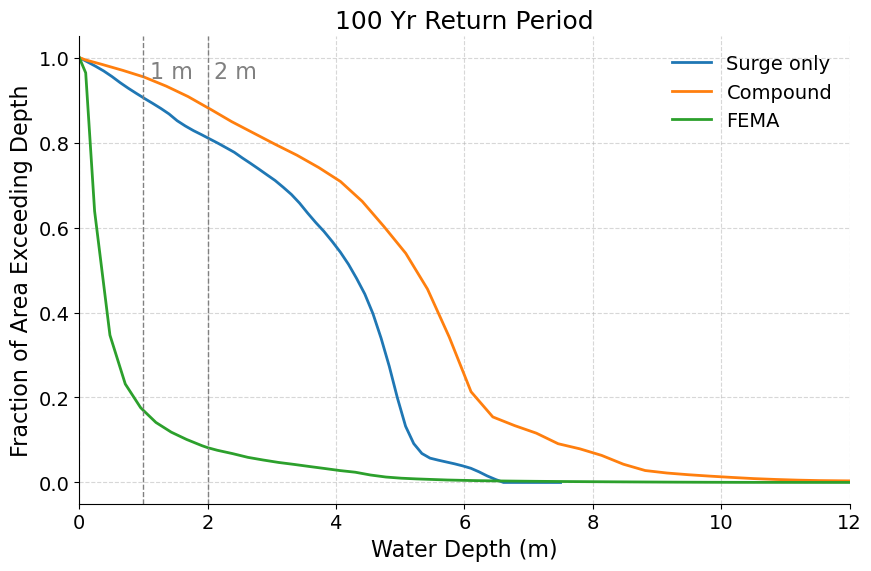

In [16]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 18,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 14,    # x tick labels
    'ytick.labelsize': 14,    # y tick labels
    'legend.fontsize': 14,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Surge only (100-yr)": r"C:\Users\sahad2\Research_data\Raster\surge_only_btub_Depth_100yr_6.5_msk_nonnegative.tif",
    "Compound flood (100-yr)": r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_100yr.tif",
    "FEMA 100-yr flood": r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.0   # cells >= this are considered "flooded" when using DENOMINATOR="flooded"
DENOMINATOR = "flooded"          # "land" or "flooded"
DEPTH_CAP = None              # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 60                 # curve resolution
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # ensure these are included
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData -> NaN, negatives -> NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    # Optional cap (e.g., 0–5 m)
    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel area (m²) from transform
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # Land area from boundary in raster CRS (m²)
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def is_binary_extent(vals, tol=1e-9):
    """Heuristic: treat as extent if unique finite values subset of {0, 1} (within tol)."""
    u = np.unique(vals)
    u = u[np.isfinite(u)]
    if u.size == 0:
        return False
    return np.all((np.abs(u - 0) < tol) | (np.abs(u - 1) < tol))

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(9, 6))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    # Determine if this raster is a binary flood extent (e.g., FEMA)
    valid_vals = depth_ma.compressed()
    treat_as_extent = is_binary_extent(valid_vals)

    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # Threshold range
    if treat_as_extent:
        dmin, dmax = 0.0, 1.0
    else:
        dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
        dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    # Denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH) if not treat_as_extent else (depth_ma > 0)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    # Exceedance fractions
    frac = []
    if treat_as_extent:
        for t in thresholds:
            exceed_area_m2 = flooded_area_m2 if t <= 1.0 else 0.0
            frac.append(exceed_area_m2 / denom_area_m2)
    else:
        for t in thresholds:
            exceed_mask = (depth_ma >= t)
            exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
            frac.append(exceed_area_m2 / denom_area_m2)

    # Store & plot
    df = pd.DataFrame({
        "layer": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks ----
# Remove top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels and title
ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
ax.set_title("100 Yr Return Period")

# Grid
ax.grid(True, linestyle="--", alpha=0.5)

# Axis limits
ax.set_xlim(0, 12)

# Vertical guide lines at 1 m and 2 m
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=16, color='gray')

# --- Custom legend labels (no title) ---
custom_labels = {
    "Surge only (100-yr)": "Surge only",
    "Compound flood (100-yr)": "Compound",
    "FEMA 100-yr flood": "FEMA"
}
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [custom_labels.get(l, l) for l in labels], frameon=False)

plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr.csv


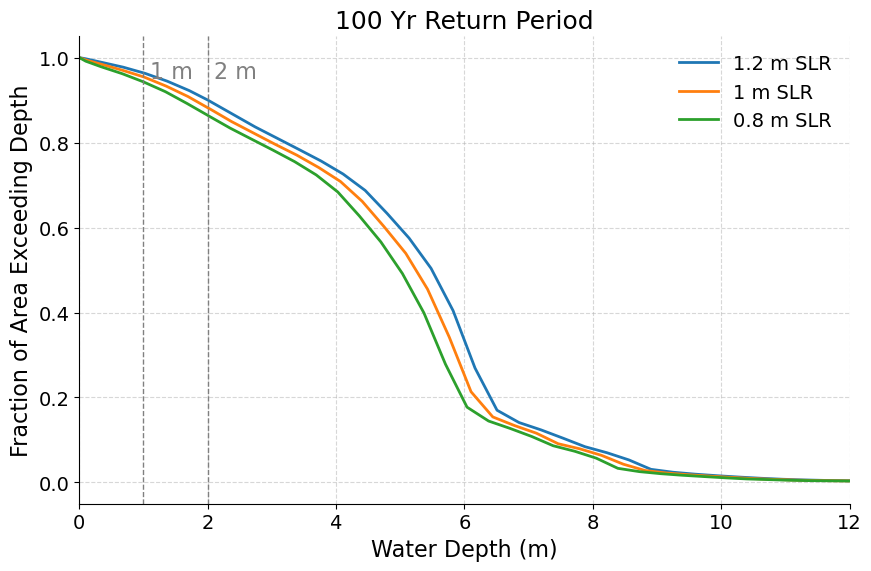

In [20]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 18,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 14,    # x tick labels
    'ytick.labelsize': 14,    # y tick labels
    'legend.fontsize': 14,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "1.2 m SLR": r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif",
    "1 m SLR": r"C:\Users\sahad2\Research_data\Raster\Compound_flood_sim_depth\sim_depth_100yr.tif",
    "0.8 m SLR": "D:\Phd Research\sim_depth_100yr_0.8SLR.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.0   # cells >= this are considered "flooded" when using DENOMINATOR="flooded"
DENOMINATOR = "flooded"          # "land" or "flooded"
DEPTH_CAP = None              # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 60                 # curve resolution
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # ensure these are included
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData -> NaN, negatives -> NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    # Optional cap (e.g., 0–5 m)
    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel area (m²) from transform
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # Land area from boundary in raster CRS (m²)
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def is_binary_extent(vals, tol=1e-9):
    """Heuristic: treat as extent if unique finite values subset of {0, 1} (within tol)."""
    u = np.unique(vals)
    u = u[np.isfinite(u)]
    if u.size == 0:
        return False
    return np.all((np.abs(u - 0) < tol) | (np.abs(u - 1) < tol))

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(9, 6))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    # Determine if this raster is a binary flood extent (e.g., FEMA)
    valid_vals = depth_ma.compressed()
    treat_as_extent = is_binary_extent(valid_vals)

    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # Threshold range
    if treat_as_extent:
        dmin, dmax = 0.0, 1.0
    else:
        dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
        dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    # Denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH) if not treat_as_extent else (depth_ma > 0)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    # Exceedance fractions
    frac = []
    if treat_as_extent:
        for t in thresholds:
            exceed_area_m2 = flooded_area_m2 if t <= 1.0 else 0.0
            frac.append(exceed_area_m2 / denom_area_m2)
    else:
        for t in thresholds:
            exceed_mask = (depth_ma >= t)
            exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
            frac.append(exceed_area_m2 / denom_area_m2)

    # Store & plot
    df = pd.DataFrame({
        "layer": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks ----
# Remove top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels and title
ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
ax.set_title("100 Yr Return Period")

# Grid
ax.grid(True, linestyle="--", alpha=0.5)

# Axis limits
ax.set_xlim(0, 12)

# Vertical guide lines at 1 m and 2 m
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=16, color='gray')

# --- Custom legend labels (no title) ---
custom_labels = {
    "1.2 m SLR": "1.2 m SLR",
    "1 m SLR": "1 m SLR",
    "0.8 m SLR": "0.8 m SLR"
}
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [custom_labels.get(l, l) for l in labels], frameon=False)

plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr_sensitivity.csv


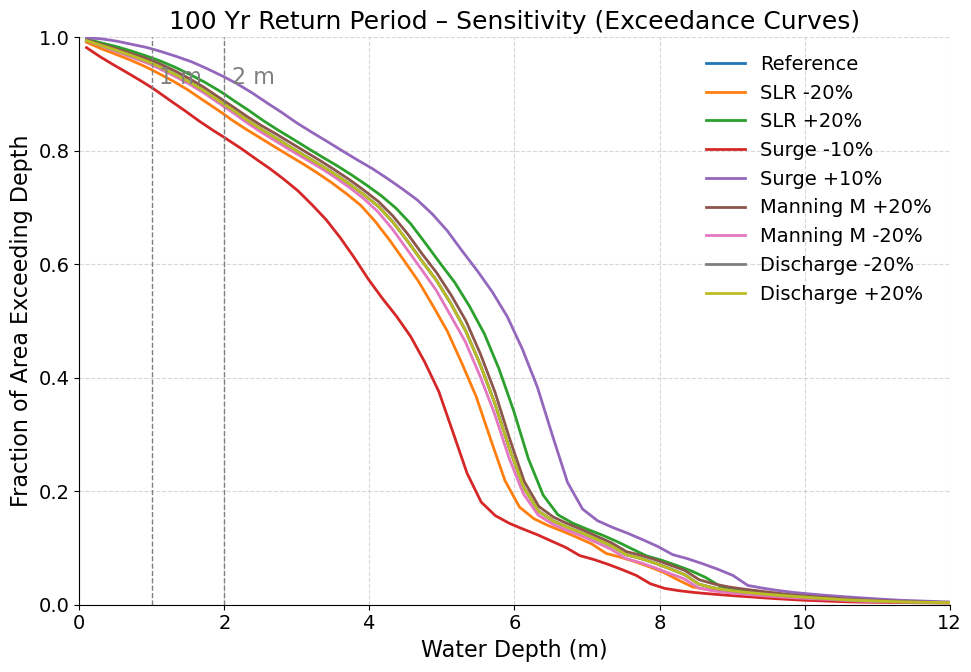

In [26]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 18,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 14,    # x tick labels
    'ytick.labelsize': 14,    # y tick labels
    'legend.fontsize': 14,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\sim_depth_100yr.tif",
    "SLR -20% ": r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif",
    "SLR +20% ": r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif",
    "Surge -10%": r"D:\Phd Research\sim_depth_100yr_surge_M10.tif",
    "Surge +10%": r"D:\Phd Research\sim_depth_100yr_surge_P10.tif",
    "Manning M +20%": r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif",
    "Manning M -20%": r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif",
    "Discharge -20%": r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif",
    "Discharge +20%": r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this (used when denominator="flooded")
DENOMINATOR = "land"         # "land" or "flooded" (like your last code)
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 100                  # curve resolution (higher for smoother sampling)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # ensure these are included
SMOOTH_WINDOW = 8               # odd integer >= 3; rolling average window for smoothing lines
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData -> NaN, negatives -> NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    # Optional cap (e.g., 0–5 m)
    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel area (m²)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # Land area (m²)
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    """
    Simple moving average smoother (odd window). Keeps endpoints by padding.
    """
    if window is None or window < 3 or window % 2 == 0:
        return y
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(10, 7))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # Threshold range
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    # Denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    # Exceedance fractions
    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    # Smooth the fraction series
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)

    # Store & plot
    df = pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks ----
# Remove top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Labels and title
ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
ax.set_title("100 Yr Return Period – Sensitivity (Exceedance Curves)")

# Grid & limits
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)  # nice probability scale

# Vertical guide lines at 1 m and 2 m
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=16, color='gray')

# Legend (no title)
ax.legend(frameon=False, ncol=1)

plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr_sensitivity.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr_sensitivity_bands.csv


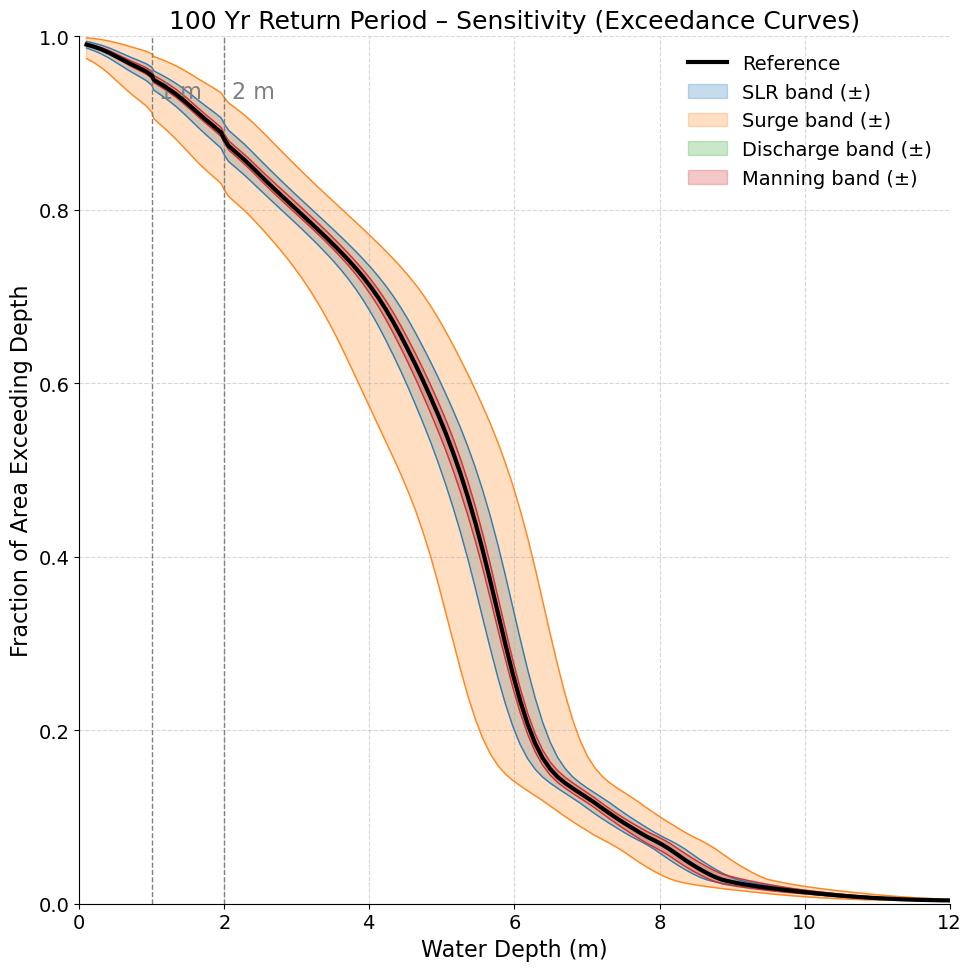

In [9]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 18,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 14,    # x tick labels
    'ytick.labelsize': 14,    # y tick labels
    'legend.fontsize': 14,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\sim_depth_100yr.tif",

    "SLR -20%": r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif",
    "SLR +20%": r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif",

    "Surge -10%": r"D:\Phd Research\sim_depth_100yr_surge_M10.tif",
    "Surge +10%": r"D:\Phd Research\sim_depth_100yr_surge_P10.tif",

    "Manning -20%": r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif",
    "Manning +20%": r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif",

    "Discharge -20%": r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif",
    "Discharge +20%": r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Manning":   {"minus": "Manning -20%",   "plus": "Manning +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

# ===================== PLOTTING =====================
fig, ax = plt.subplots(figsize=(10, 10))

# 1) Bold reference line
if "Reference" in curves:
    ax.plot(thresholds, curves["Reference"], color="black", linewidth=3, label="Reference", zorder=10)

# 2) Shaded bands for each driver
for driver, spec in GROUPS.items():
    minus_lbl = spec["minus"]
    plus_lbl  = spec["plus"]
    color     = spec["color"]

    if minus_lbl in curves and plus_lbl in curves:
        y_minus = curves[minus_lbl]
        y_plus  = curves[plus_lbl]

        # Some rasters might not have values across entire threshold span; guard NaNs
        y_low  = np.nanmin(np.vstack([y_minus, y_plus]), axis=0)
        y_high = np.nanmax(np.vstack([y_minus, y_plus]), axis=0)

        # Fill band
        ax.fill_between(thresholds, y_low, y_high, color=color, alpha=0.25, label=f"{driver} band (±)")
        # Optional: draw thin outlines for the two edges
        ax.plot(thresholds, y_minus, color=color, linewidth=1, alpha=0.9)
        ax.plot(thresholds, y_plus,  color=color, linewidth=1, alpha=0.9)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
ax.set_title("100 Yr Return Period – Sensitivity (Exceedance Curves)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

# Vertical guides
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=16, color='gray')

# Legend (order: Reference then bands)
handles, labels = ax.get_legend_handles_labels()

# Move "Reference" to front if present
if "Reference" in labels:
    ref_idx = labels.index("Reference")
    # put reference first
    new_order = [ref_idx] + [i for i in range(len(labels)) if i != ref_idx]
    handles = [handles[i] for i in new_order]
    labels  = [labels[i]  for i in new_order]

ax.legend(handles, labels, frameon=False, ncol=1)

plt.tight_layout()

# Save CSV with all curves on common thresholds
rows = []
for label, y in curves.items():
    rows.append(pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": y
    }))
if rows:
    df_all = pd.concat(rows, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr_sensitivity_bands.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_compound_5-100yr.csv


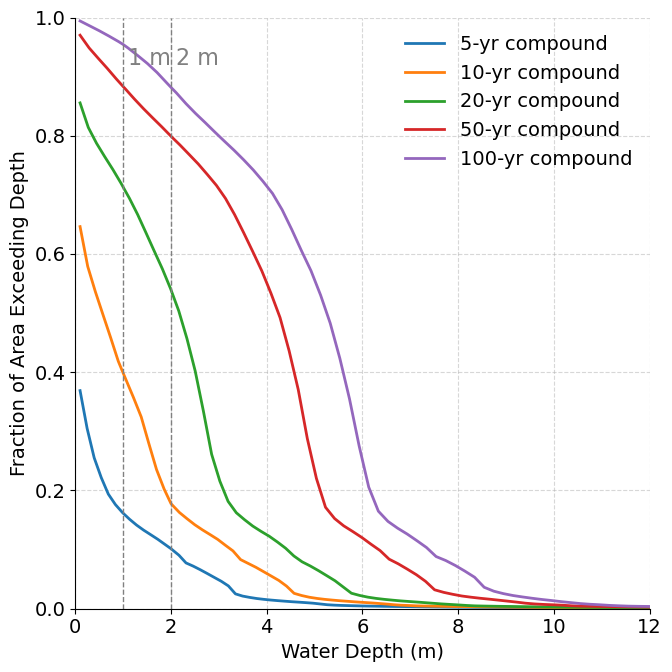

In [8]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "5-yr compound":  r"D:\Phd Research\inundation depth 5 yr compound.tif",
    "10-yr compound": r"D:\Phd Research\inundation depth 10 yr compound.tif",
    "20-yr compound": r"D:\Phd Research\inundation depth 20 yr compound.tif",
    "50-yr compound": r"D:\Phd Research\inundation depth 50 yr compound.tif",
    "100-yr compound":r"D:\Phd Research\sim_depth_100yr.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1
DENOMINATOR = "land"          # "land" or "flooded"
DEPTH_CAP = None
N_THRESH = 100
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]
SMOOTH_WINDOW = 8
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return y
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(7, 7))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)

    df = pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
# ax.set_title("Compound Flooding – Exceedance Curves (5–100 yr)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=16, color='gray')

ax.legend(frameon=False, ncol=1)
plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_compound_5-100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_compound_5-100yr.csv


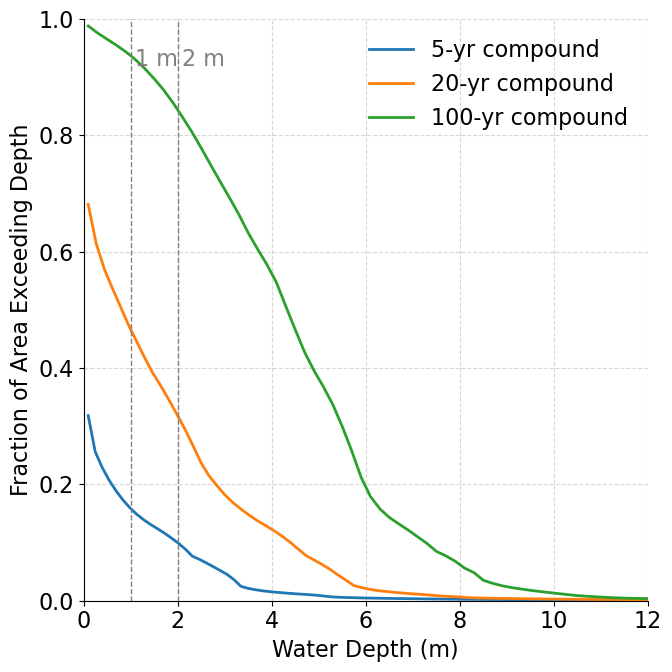

In [3]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "5-yr compound":  r"D:\Phd Research\Final_Raster\5yr_compound_flood_stat.tif",
    #"10-yr compound": r"D:\Phd Research\inundation depth 10 yr compound.tif",
    "20-yr compound": r"D:\Phd Research\Final_Raster\20yr_compound_flood_stat.tif",
    #"50-yr compound": r"D:\Phd Research\inundation depth 50 yr compound.tif",
    "100-yr compound":r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1
DENOMINATOR = "land"          # "land" or "flooded"
DEPTH_CAP = None
N_THRESH = 100
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]
SMOOTH_WINDOW = 8
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return y
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(7, 7))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)

    df = pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
# ax.set_title("Compound Flooding – Exceedance Curves (5–100 yr)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=16, color='gray')

ax.legend(frameon=False, ncol=1)
plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_compound_5-100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_compound_5-100yr.csv


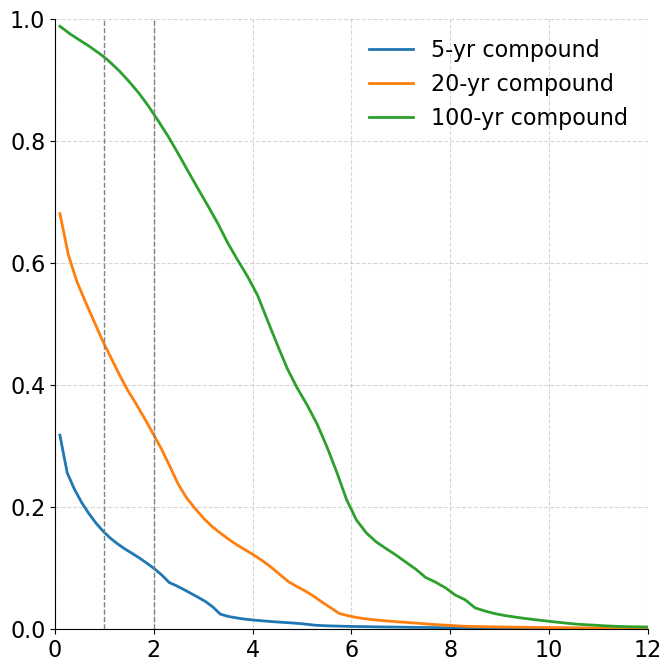

In [4]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "5-yr compound":  r"D:\Phd Research\Final_Raster\5yr_compound_flood_stat.tif",
    #"10-yr compound": r"D:\Phd Research\inundation depth 10 yr compound.tif",
    "20-yr compound": r"D:\Phd Research\Final_Raster\20yr_compound_flood_stat.tif",
    #"50-yr compound": r"D:\Phd Research\inundation depth 50 yr compound.tif",
    "100-yr compound":r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1
DENOMINATOR = "land"          # "land" or "flooded"
DEPTH_CAP = None
N_THRESH = 100
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]
SMOOTH_WINDOW = 8
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return y
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(7, 7))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)

    df = pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xlabel("Water Depth (m)")
# ax.set_ylabel("Fraction of Area Exceeding Depth")
# ax.set_title("Compound Flooding – Exceedance Curves (5–100 yr)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    # ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
    #         va='top', fontsize=16, color='gray')

ax.legend(frameon=False, ncol=1)
plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_compound_5-100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_compound_5-100yr.csv


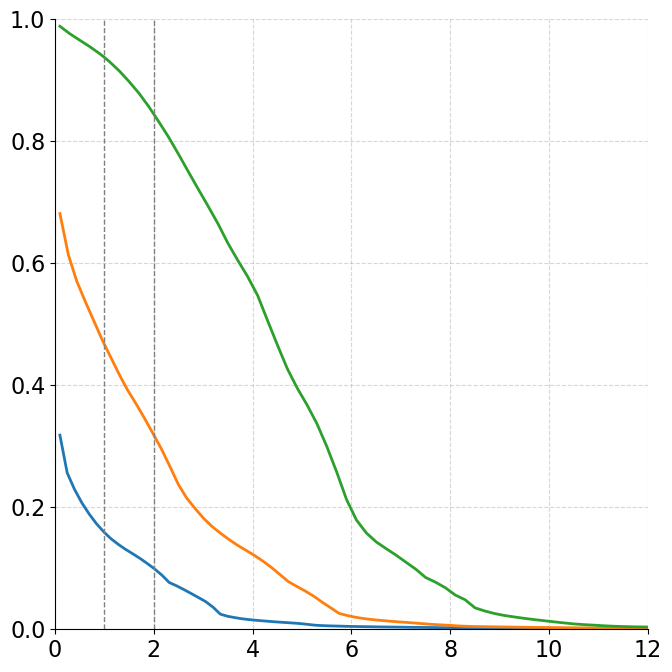

In [1]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "5-yr compound":  r"D:\Phd Research\Final_Raster\5yr_compound_flood_stat.tif",
    #"10-yr compound": r"D:\Phd Research\inundation depth 10 yr compound.tif",
    "20-yr compound": r"D:\Phd Research\Final_Raster\20yr_compound_flood_stat.tif",
    #"50-yr compound": r"D:\Phd Research\inundation depth 50 yr compound.tif",
    "100-yr compound":r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1
DENOMINATOR = "land"          # "land" or "flooded"
DEPTH_CAP = None
N_THRESH = 100
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]
SMOOTH_WINDOW = 8
# -------------------------------------------------

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return y
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# Load boundary
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(7, 7))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    thr_auto = np.linspace(dmin, dmax, N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, dmax))

    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)

    df = pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)
    ax.plot(thresholds, frac, label=label, linewidth=2)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xlabel("Water Depth (m)")
# ax.set_ylabel("Fraction of Area Exceeding Depth")
# ax.set_title("Compound Flooding – Exceedance Curves (5–100 yr)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    # ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
    #         va='top', fontsize=16, color='gray')

# ax.legend(frameon=False, ncol=1)
plt.tight_layout()

# Save CSV with all curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_compound_5-100yr.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr_sensitivity_bands.csv


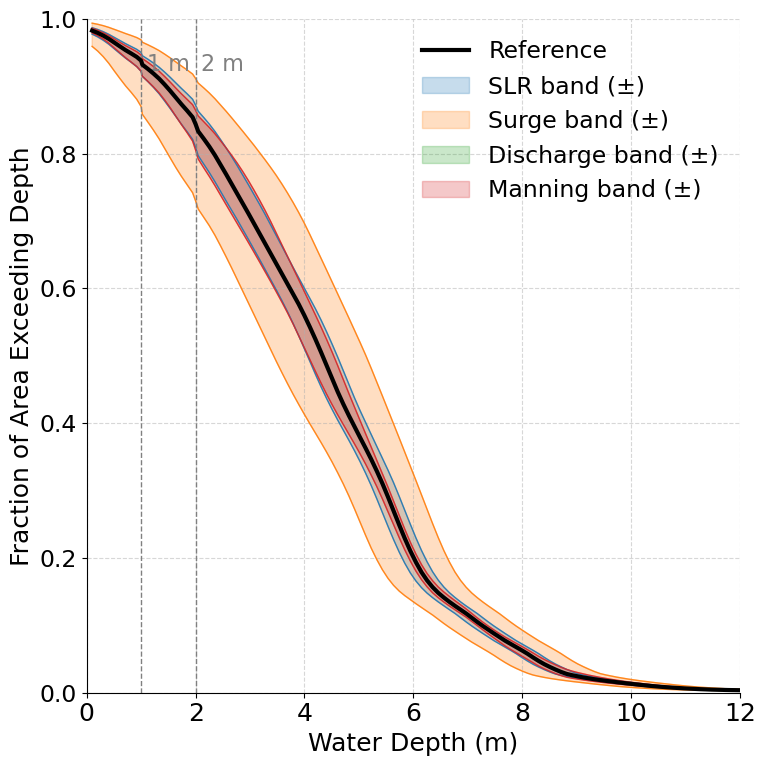

In [2]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 18,          # base font size
    'axes.titlesize': 18,     # title
    'axes.labelsize': 18,     # x and y labels
    'xtick.labelsize': 18,    # x tick labels
    'ytick.labelsize': 17,    # y tick labels
    'legend.fontsize': 17,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Manning -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Manning +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Manning":   {"minus": "Manning -20%",   "plus": "Manning +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

# ===================== PLOTTING =====================
fig, ax = plt.subplots(figsize=(8, 8))

# 1) Bold reference line
if "Reference" in curves:
    ax.plot(thresholds, curves["Reference"], color="black", linewidth=3, label="Reference", zorder=10)

# 2) Shaded bands for each driver
for driver, spec in GROUPS.items():
    minus_lbl = spec["minus"]
    plus_lbl  = spec["plus"]
    color     = spec["color"]

    if minus_lbl in curves and plus_lbl in curves:
        y_minus = curves[minus_lbl]
        y_plus  = curves[plus_lbl]

        # Some rasters might not have values across entire threshold span; guard NaNs
        y_low  = np.nanmin(np.vstack([y_minus, y_plus]), axis=0)
        y_high = np.nanmax(np.vstack([y_minus, y_plus]), axis=0)

        # Fill band
        ax.fill_between(thresholds, y_low, y_high, color=color, alpha=0.25, label=f"{driver} band (±)")
        # Optional: draw thin outlines for the two edges
        ax.plot(thresholds, y_minus, color=color, linewidth=1, alpha=0.9)
        ax.plot(thresholds, y_plus,  color=color, linewidth=1, alpha=0.9)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Area Exceeding Depth")
# ax.set_title("100 Yr Return Period – Sensitivity (Exceedance Curves)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

# Vertical guides
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=16, color='gray')

# Legend (order: Reference then bands)
handles, labels = ax.get_legend_handles_labels()

# Move "Reference" to front if present
if "Reference" in labels:
    ref_idx = labels.index("Reference")
    # put reference first
    new_order = [ref_idx] + [i for i in range(len(labels)) if i != ref_idx]
    handles = [handles[i] for i in new_order]
    labels  = [labels[i]  for i in new_order]

ax.legend(handles, labels, frameon=False, ncol=1)

plt.tight_layout()

# Save CSV with all curves on common thresholds
rows = []
for label, y in curves.items():
    rows.append(pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": y
    }))
if rows:
    df_all = pd.concat(rows, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr_sensitivity_bands.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr_sensitivity_bands.csv


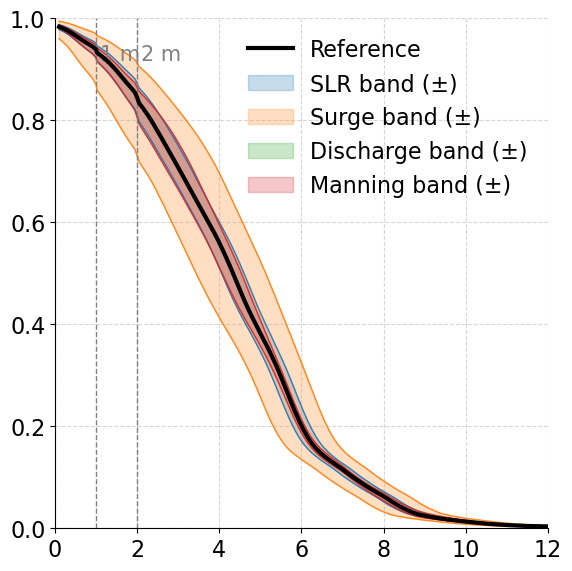

In [3]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 16,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.fontsize': 16,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Manning -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Manning +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Manning":   {"minus": "Manning -20%",   "plus": "Manning +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

# ===================== PLOTTING =====================
fig, ax = plt.subplots(figsize=(6, 6))

# 1) Bold reference line
if "Reference" in curves:
    ax.plot(thresholds, curves["Reference"], color="black", linewidth=3, label="Reference", zorder=10)

# 2) Shaded bands for each driver
for driver, spec in GROUPS.items():
    minus_lbl = spec["minus"]
    plus_lbl  = spec["plus"]
    color     = spec["color"]

    if minus_lbl in curves and plus_lbl in curves:
        y_minus = curves[minus_lbl]
        y_plus  = curves[plus_lbl]

        # Some rasters might not have values across entire threshold span; guard NaNs
        y_low  = np.nanmin(np.vstack([y_minus, y_plus]), axis=0)
        y_high = np.nanmax(np.vstack([y_minus, y_plus]), axis=0)

        # Fill band
        ax.fill_between(thresholds, y_low, y_high, color=color, alpha=0.25, label=f"{driver} band (±)")
        # Optional: draw thin outlines for the two edges
        ax.plot(thresholds, y_minus, color=color, linewidth=1, alpha=0.9)
        ax.plot(thresholds, y_plus,  color=color, linewidth=1, alpha=0.9)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.set_xlabel("Water Depth (m)")
#ax.set_ylabel("Fraction of Area Exceeding Depth")
# ax.set_title("100 Yr Return Period – Sensitivity (Exceedance Curves)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

# Vertical guides
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=15, color='gray')

# Legend (order: Reference then bands)
handles, labels = ax.get_legend_handles_labels()

# Move "Reference" to front if present
if "Reference" in labels:
    ref_idx = labels.index("Reference")
    # put reference first
    new_order = [ref_idx] + [i for i in range(len(labels)) if i != ref_idx]
    handles = [handles[i] for i in new_order]
    labels  = [labels[i]  for i in new_order]

ax.legend(handles, labels, frameon=False, ncol=1)

plt.tight_layout()

# Save CSV with all curves on common thresholds
rows = []
for label, y in curves.items():
    rows.append(pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": y
    }))
if rows:
    df_all = pd.concat(rows, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr_sensitivity_bands.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr_sensitivity_bands.csv


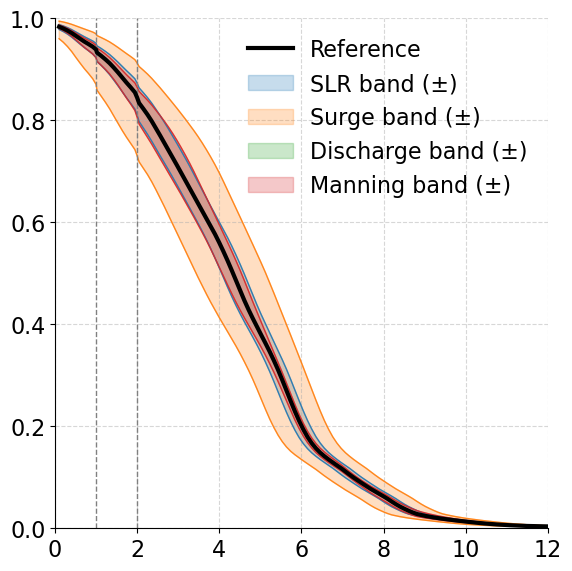

In [3]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 16,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.fontsize': 16,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Manning -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Manning +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Manning":   {"minus": "Manning -20%",   "plus": "Manning +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

# ===================== PLOTTING =====================
fig, ax = plt.subplots(figsize=(6, 6))

# 1) Bold reference line
if "Reference" in curves:
    ax.plot(thresholds, curves["Reference"], color="black", linewidth=3, label="Reference", zorder=10)

# 2) Shaded bands for each driver
for driver, spec in GROUPS.items():
    minus_lbl = spec["minus"]
    plus_lbl  = spec["plus"]
    color     = spec["color"]

    if minus_lbl in curves and plus_lbl in curves:
        y_minus = curves[minus_lbl]
        y_plus  = curves[plus_lbl]

        # Some rasters might not have values across entire threshold span; guard NaNs
        y_low  = np.nanmin(np.vstack([y_minus, y_plus]), axis=0)
        y_high = np.nanmax(np.vstack([y_minus, y_plus]), axis=0)

        # Fill band
        ax.fill_between(thresholds, y_low, y_high, color=color, alpha=0.25, label=f"{driver} band (±)")
        # Optional: draw thin outlines for the two edges
        ax.plot(thresholds, y_minus, color=color, linewidth=1, alpha=0.9)
        ax.plot(thresholds, y_plus,  color=color, linewidth=1, alpha=0.9)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.set_xlabel("Water Depth (m)")
#ax.set_ylabel("Fraction of Area Exceeding Depth")
# ax.set_title("100 Yr Return Period – Sensitivity (Exceedance Curves)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

# Vertical guides
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
#     ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
#             va='top', fontsize=15, color='gray')

# Legend (order: Reference then bands)
handles, labels = ax.get_legend_handles_labels()

# Move "Reference" to front if present
if "Reference" in labels:
    ref_idx = labels.index("Reference")
    # put reference first
    new_order = [ref_idx] + [i for i in range(len(labels)) if i != ref_idx]
    handles = [handles[i] for i in new_order]
    labels  = [labels[i]  for i in new_order]

ax.legend(handles, labels, frameon=False, ncol=1)

plt.tight_layout()

# Save CSV with all curves on common thresholds
rows = []
for label, y in curves.items():
    rows.append(pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": y
    }))
if rows:
    df_all = pd.concat(rows, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr_sensitivity_bands.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


Saved exceedance data to: C:\Users\sahad2\depth_exceedance_curves_100yr_sensitivity_bands.csv


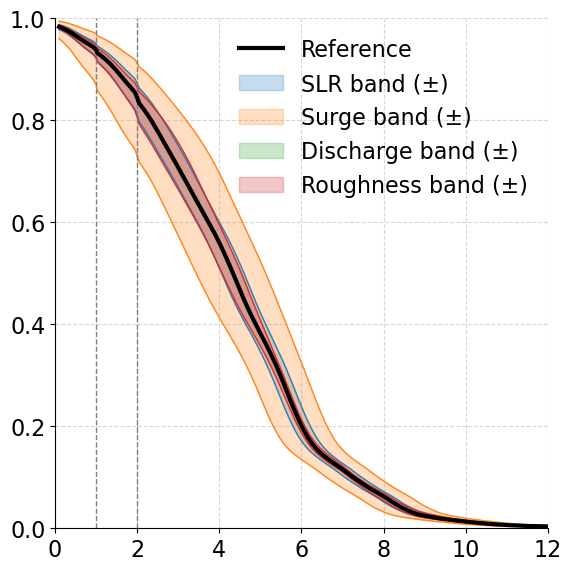

In [1]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 16,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.fontsize': 16,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Roughness -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Roughness +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Roughness":   {"minus": "Roughness -20%",   "plus": "Roughness +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

# ===================== PLOTTING =====================
fig, ax = plt.subplots(figsize=(6, 6))

# 1) Bold reference line
if "Reference" in curves:
    ax.plot(thresholds, curves["Reference"], color="black", linewidth=3, label="Reference", zorder=10)

# 2) Shaded bands for each driver
for driver, spec in GROUPS.items():
    minus_lbl = spec["minus"]
    plus_lbl  = spec["plus"]
    color     = spec["color"]

    if minus_lbl in curves and plus_lbl in curves:
        y_minus = curves[minus_lbl]
        y_plus  = curves[plus_lbl]

        # Some rasters might not have values across entire threshold span; guard NaNs
        y_low  = np.nanmin(np.vstack([y_minus, y_plus]), axis=0)
        y_high = np.nanmax(np.vstack([y_minus, y_plus]), axis=0)

        # Fill band
        ax.fill_between(thresholds, y_low, y_high, color=color, alpha=0.25, label=f"{driver} band (±)")
        # Optional: draw thin outlines for the two edges
        ax.plot(thresholds, y_minus, color=color, linewidth=1, alpha=0.9)
        ax.plot(thresholds, y_plus,  color=color, linewidth=1, alpha=0.9)

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.set_xlabel("Water Depth (m)")
#ax.set_ylabel("Fraction of Area Exceeding Depth")
# ax.set_title("100 Yr Return Period – Sensitivity (Exceedance Curves)")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)

# Vertical guides
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
#     ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
#             va='top', fontsize=15, color='gray')

# Legend (order: Reference then bands)
handles, labels = ax.get_legend_handles_labels()

# Move "Reference" to front if present
if "Reference" in labels:
    ref_idx = labels.index("Reference")
    # put reference first
    new_order = [ref_idx] + [i for i in range(len(labels)) if i != ref_idx]
    handles = [handles[i] for i in new_order]
    labels  = [labels[i]  for i in new_order]

ax.legend(handles, labels, frameon=False, ncol=1)

plt.tight_layout()

# Save CSV with all curves on common thresholds
rows = []
for label, y in curves.items():
    rows.append(pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": y
    }))
if rows:
    df_all = pd.concat(rows, ignore_index=True)
    out_csv = Path.cwd() / "depth_exceedance_curves_100yr_sensitivity_bands.csv"
    df_all.to_csv(out_csv, index=False)
    print(f"Saved exceedance data to: {out_csv}")

plt.show()


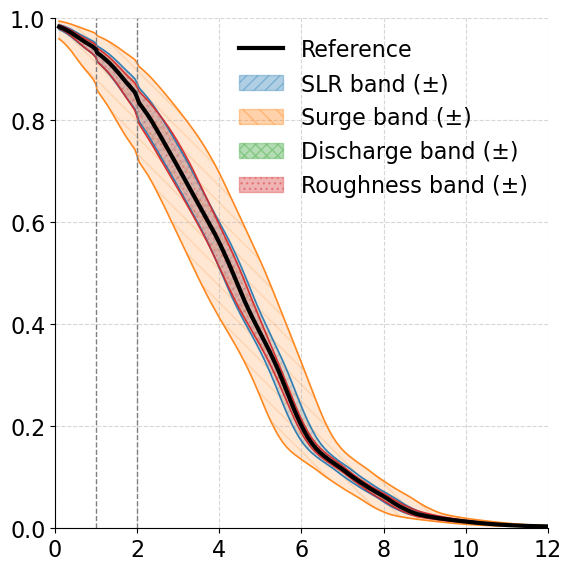

In [10]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 16,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.fontsize': 16,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Roughness -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Roughness +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Roughness":   {"minus": "Roughness -20%",   "plus": "Roughness +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

# ===================== PLOTTING: SINGLE PLOT WITH HATCHING =====================

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig,ax=plt.subplots(figsize=(6,6))

# Keep original driver order
driver_order=["SLR","Surge","Discharge","Roughness"]

# Different hatch pattern for each sensitivity band
hatches={
    "SLR":"///",
    "Surge":"\\\\",
    "Discharge":"xxx",
    "Roughness":"..."
}

# Plot all sensitivity bands
for driver in driver_order:
    spec=GROUPS[driver]
    y_minus=curves[spec["minus"]]; y_plus=curves[spec["plus"]]
    y_low=np.minimum(y_minus,y_plus); y_high=np.maximum(y_minus,y_plus)

    # Colored sensitivity band + hatch
    ax.fill_between(thresholds,y_low,y_high,
                    facecolor=spec["color"],alpha=.18,
                    edgecolor=spec["color"],hatch=hatches[driver],
                    linewidth=.8)

    # Band boundaries
    ax.plot(thresholds,y_minus,color=spec["color"],linewidth=1.2,alpha=.9)
    ax.plot(thresholds,y_plus,color=spec["color"],linewidth=1.2,alpha=.9)

# Reference line on top
ax.plot(thresholds,curves["Reference"],color="black",linewidth=3,zorder=10)

# Presentation
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True,linestyle="--",alpha=.5)
ax.set_xlim(0,12)
ax.set_ylim(0,1)

# Vertical guides
for d in [1.0,2.0]:
    ax.axvline(x=d,color="gray",linestyle="--",linewidth=1)

# Custom legend: original names + original order + hatch patterns
legend_handles=[
    Line2D([0],[0],color="black",linewidth=3,label="Reference"),

    Patch(facecolor=GROUPS["SLR"]["color"],edgecolor=GROUPS["SLR"]["color"],
          alpha=.35,hatch=hatches["SLR"],label="SLR band (±)"),

    Patch(facecolor=GROUPS["Surge"]["color"],edgecolor=GROUPS["Surge"]["color"],
          alpha=.35,hatch=hatches["Surge"],label="Surge band (±)"),

    Patch(facecolor=GROUPS["Discharge"]["color"],edgecolor=GROUPS["Discharge"]["color"],
          alpha=.35,hatch=hatches["Discharge"],label="Discharge band (±)"),

    Patch(facecolor=GROUPS["Roughness"]["color"],edgecolor=GROUPS["Roughness"]["color"],
          alpha=.35,hatch=hatches["Roughness"],label="Roughness band (±)")
]

ax.legend(handles=legend_handles,frameon=False,ncol=1)

plt.tight_layout()
plt.show()

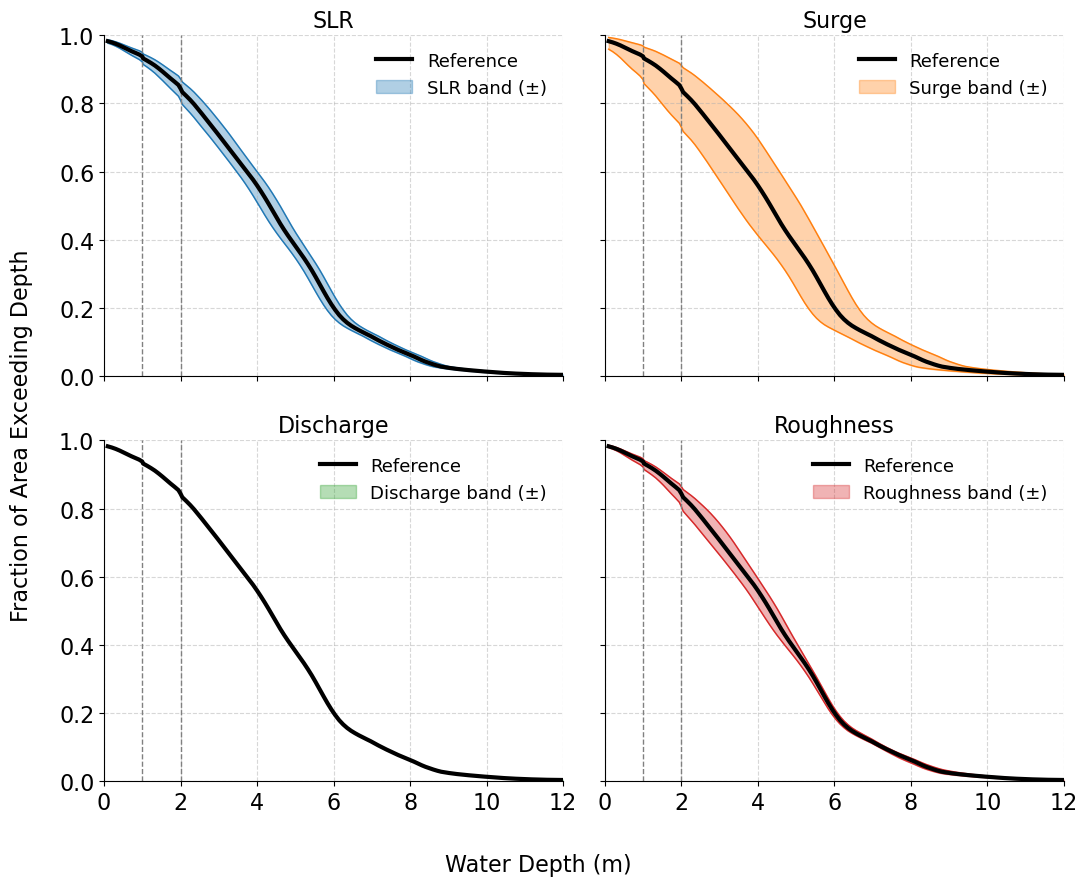

In [6]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 16,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.fontsize': 16,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Roughness -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Roughness +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Roughness":   {"minus": "Roughness -20%",   "plus": "Roughness +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 16,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.fontsize': 16,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Roughness -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Roughness +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Roughness":   {"minus": "Roughness -20%",   "plus": "Roughness +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 16,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.fontsize': 16,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Roughness -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Roughness +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Roughness":   {"minus": "Roughness -20%",   "plus": "Roughness +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 16,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.fontsize': 16,    # legend text
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
raster_paths = {
    "Reference": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",

    "SLR -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
    "SLR +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif",

    "Surge -10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
    "Surge +10%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif",

    "Roughness -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif",
    "Roughness +20%": r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",

    "Discharge -20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
    "Discharge +20%": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1     # flooded if depth >= this
DENOMINATOR = "land"            # "land" or "flooded"
DEPTH_CAP = None                # e.g., set 5.0 to restrict to 0–5 m; None = no cap
N_THRESH = 200                  # common curve resolution (higher = smoother)
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]  # always include these
SMOOTH_WINDOW = 7               # odd integer >=3 (moving average smoother)
# -------------------------------------------------

# Group definitions for bands
GROUPS = {
    "SLR":       {"minus": "SLR -20%",       "plus": "SLR +20%",       "color": "tab:blue"},
    "Surge":     {"minus": "Surge -10%",     "plus": "Surge +10%",     "color": "tab:orange"},
    "Discharge": {"minus": "Discharge -20%", "plus": "Discharge +20%", "color": "tab:green"},
    "Roughness":   {"minus": "Roughness -20%",   "plus": "Roughness +20%",   "color": "tab:red"},
}

def load_clip_depth(raster_path, boundary_gdf):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean: NoData/negatives/NaN
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)

    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel & land areas
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return np.asarray(y, dtype=float)
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# ---------- Load boundary ----------
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

# ---------- First pass: load all rasters and cache arrays ----------
cache = {}  # label -> dict(depth_ma, cell_area_m2, land_area_m2, dmin, dmax)
global_min = np.inf
global_max = -np.inf

for label, path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # dmin/dmax per raster (respect FLOOD_PRESENCE_THRESH and DEPTH_CAP)
    dmin = max(FLOOD_PRESENCE_THRESH, float(np.nanmin(valid_vals)))
    dmax = float(np.nanmax(valid_vals)) if DEPTH_CAP is None else min(DEPTH_CAP, float(np.nanmax(valid_vals)))

    cache[label] = {
        "depth_ma": depth_ma,
        "cell_area_m2": cell_area_m2,
        "land_area_m2": land_area_m2,
        "dmin": dmin,
        "dmax": dmax,
    }

    global_min = min(global_min, dmin)
    global_max = max(global_max, dmax)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise RuntimeError("Could not determine global threshold range (no valid rasters?).")

# Build common thresholds (include manual points, clip to [global_min, global_max])
thr_auto = np.linspace(global_min, global_max, N_THRESH)
thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), global_min, global_max))

# ---------- Helper: compute fraction curve on common thresholds ----------
def fraction_curve(depth_ma, cell_area_m2, land_area_m2, thresholds):
    # denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        return np.full_like(thresholds, np.nan, dtype=float)

    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)
    frac = np.array(frac, dtype=float)
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)
    return frac

# ---------- Compute curves for all labels on the common thresholds ----------
curves = {}  # label -> fractions
for label, meta in cache.items():
    curves[label] = fraction_curve(meta["depth_ma"], meta["cell_area_m2"], meta["land_area_m2"], thresholds)

# ===================== PLOTTING: 2 × 2 SENSITIVITY BANDS =====================

fig,axes=plt.subplots(2,2,figsize=(11,9),sharex=True,sharey=True)
axes=axes.ravel()

# Keep original driver order
driver_order=["SLR","Surge","Discharge","Roughness"]

for ax,driver in zip(axes,driver_order):
    spec=GROUPS[driver]; y_minus=curves[spec["minus"]]; y_plus=curves[spec["plus"]]
    y_low=np.minimum(y_minus,y_plus); y_high=np.maximum(y_minus,y_plus)

    # Reference line
    ax.plot(thresholds,curves["Reference"],color="black",linewidth=3,label="Reference",zorder=10)

    # Sensitivity band with original legend name
    ax.fill_between(thresholds,y_low,y_high,color=spec["color"],alpha=.35,label=f"{driver} band (±)")
    ax.plot(thresholds,y_minus,color=spec["color"],linewidth=1)
    ax.plot(thresholds,y_plus,color=spec["color"],linewidth=1)

    # Vertical guides
    for d in [1,2]: ax.axvline(d,color="gray",linestyle="--",linewidth=1)

    # Formatting
    ax.set_title(driver)
    ax.set_xlim(0,12); ax.set_ylim(0,1)
    ax.grid(True,linestyle="--",alpha=.5)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(frameon=False,fontsize=13)

# Common axis labels
fig.supxlabel("Water Depth (m)",fontsize=16)
fig.supylabel("Fraction of Area Exceeding Depth",fontsize=16)

plt.tight_layout()
plt.savefig("Sensitivity_Exceedance_4Panels.png",dpi=600,bbox_inches="tight")
plt.show()